# Etapa 3 — Análise Exploratória e Consultas SQL

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import duckdb
import pyarrow as pa
import pyarrow.parquet as pq
import re
from collections import Counter
from scipy.stats import mannwhitneyu
from sklearn.metrics import cohen_kappa_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans


# Paleta de cores consistente em todo o notebook
C_RULE    = '#2E86AB'   # azul  → regra (self-contained)
C_NORULE  = '#E84855'   # vermelho → não-regra (others)
C_BASE1   = '#2E86AB'   # ACCORD Official
C_BASE2   = '#E84855'   #Base Construida
C_BASE3   = '#F6AE2D'   # ALL.csv baseline
C_BG      = '#F8F9FA'
C_GRID    = '#DEE2E6'

plt.rcParams.update({
    'figure.facecolor': C_BG,
    'axes.facecolor':   C_BG,
    'axes.grid':        True,
    'grid.color':       C_GRID,
    'grid.linewidth':   0.8,
    'font.size':        11,
    'axes.spines.top':  False,
    'axes.spines.right':False,
})

In [2]:
PATH_ACCORD_OFFICIAL = '../data/accord_official_clean.csv'      # Base ACCORD tratada
PATH_NOSSA_BASE      = '../data/classification_dataset_cleaned(2).csv'  # Base Construida
PATH_ALL_CSV         = '../data/all.csv'                        # Baseline 862 sentenças
OUTPUT_PARQUET       = '../data/dataset_tidy.parquet'           # Saída Parquet (Etapa 2)

In [3]:
df_all = pd.read_csv(PATH_ALL_CSV)
print(f'BASE 1 — ALL (Baseline): {df_all.shape}')
print(df_all['is_rule'].value_counts())

df_official = pd.read_csv(PATH_ACCORD_OFFICIAL)
print(f'BASE 2 — ACCORD Official: {df_official.shape}')
print(df_official['is_rule'].value_counts())

df_ours = pd.read_csv(PATH_NOSSA_BASE)
print(f'BASE 3 — Base Construida: {df_ours.shape}')
print(df_ours['is_rule'].value_counts())


# Temos 284 instancias que foram coletadas baseados no CODE-ACCORD,
# uma tentativa de salvar 150 intancia sem classificação, foi utilizar as
# regras que eles definem como regra e testar. Isso pode dar mt bom ou não...


BASE 1 — ALL (Baseline): (862, 8)
is_rule
1    862
Name: count, dtype: int64
BASE 2 — ACCORD Official: (2334, 4)
is_rule
0    1566
1     768
Name: count, dtype: int64
BASE 3 — Base Construida: (2768, 3)
is_rule
0.0    1588
1.0    1180
Name: count, dtype: int64


Nesse trabalho temos 3 base de dados para serem analisadas e exploradas.
A primeira é conhecida como ALL.csv, a qual é utilizada no artigo oficial, ela contem 862 sentenças sendo todas regras anotadas por especialistas.
No repositorio é disponibilizado a base de dados com todos as sentenças retiradas dos docuemntos regulatorios. 
Contem as sentenças ja tratadas, sem repetiçoes.
Por fim, temos a base contruida para esse trabalho, ela foi montada em cima do baseline, juntando todas as sentenças retiradas no repositorio.

Uma diferença entre o ACCORD e a base construida é que 284 sentenças forma retiradas do repositorio CODE-ACCORD.
Algumas sentenças não haviam classificação, assim para salvar foi anotado esses dados na mão baseado nos marcadores deônticos.

Vemos que a base desse trabalho é mais balanceada comparada a base ACCORD oficial.

---
## Análise Estrutural das Três Bases


In [4]:
summary = []
for df, name in [(df_official,'ACCORD Official'), (df_ours,'Base Construida'), (df_all,'ALL.csv')]:
    n_total = len(df)
    n_rules = (df['is_rule'] == 1).sum()
    n_other = (df['is_rule'] == 0).sum()
    ratio   = n_other / n_rules if n_rules > 0 else float('inf')
    summary.append({
        'Base': name,
        'Total': n_total,
        'Regras (1)': n_rules,
        'Não-Regras (0)': n_other,
        '% Regras': f'{n_rules/n_total*100:.1f}%',
        'Razão 0:1': f'1:{ratio:.1f}'
    })

df_summary = pd.DataFrame(summary)
print('══ RESUMO DAS TRÊS BASES ══════════════════════════════════════════')
df_summary, df.to_csv('sumarry_databases.csv', index=False)

══ RESUMO DAS TRÊS BASES ══════════════════════════════════════════


(              Base  Total  Regras (1)  Não-Regras (0) % Regras Razão 0:1
 0  ACCORD Official   2334         768            1566    32.9%     1:2.0
 1  Base Construida   2768        1180            1588    42.6%     1:1.3
 2          ALL.csv    862         862               0   100.0%     1:0.0,
 None)

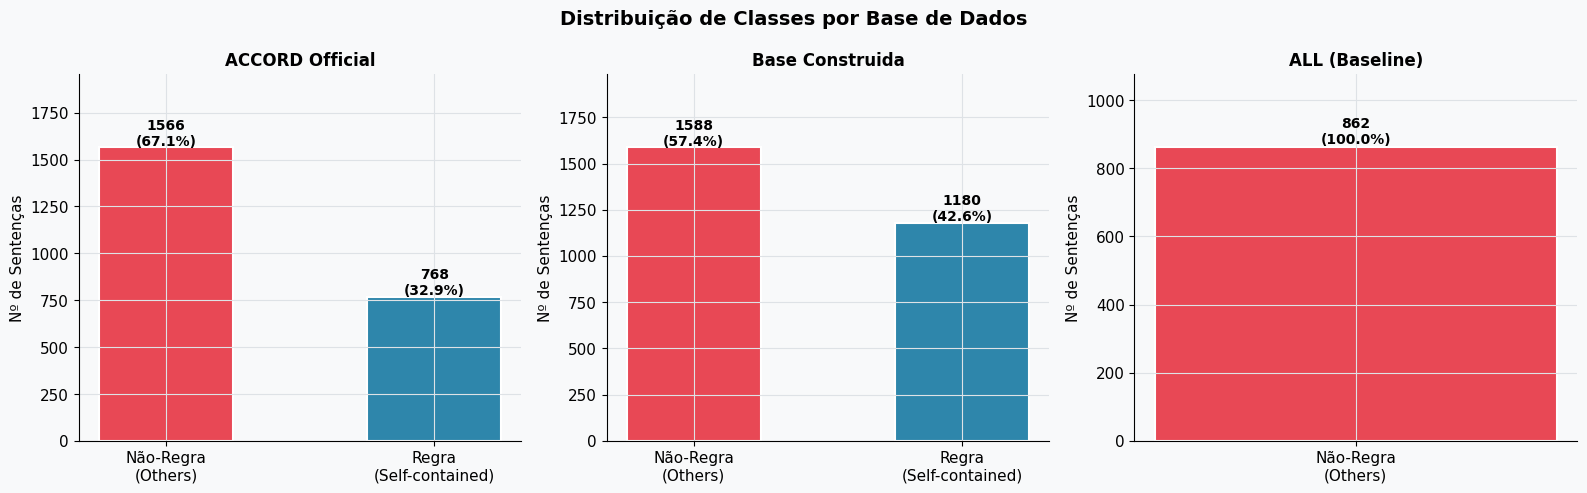

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Distribuição de Classes por Base de Dados', fontsize=14, fontweight='bold')

for ax, (df, name, color) in zip(axes, [
    (df_official, 'ACCORD Official', C_BASE1),
    (df_ours,     'Base Construida',       C_BASE2),
    (df_all,      'ALL (Baseline)',          C_BASE3)
]):
    counts = df['is_rule'].value_counts().sort_index()
    labels = ['Não-Regra\n(Others)', 'Regra\n(Self-contained)'][:len(counts)]
    colors = [C_NORULE, C_RULE][:len(counts)]
    bars   = ax.bar(labels, counts.values, color=colors, width=0.5,
                    edgecolor='white', linewidth=1.5)
    for bar, val in zip(bars, counts.values):
        pct = val / len(df) * 100
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                f'{val}\n({pct:.1f}%)', ha='center', fontsize=10, fontweight='bold')
    ax.set_title(name, fontweight='bold', fontsize=12)
    ax.set_ylabel('Nº de Sentenças')
    ax.set_ylim(0, max(counts.values) * 1.25)

plt.tight_layout()
plt.savefig('../figures/fig1_distribuicao_classes.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Preparação Tidy e Exportação Parquet

Seguindo os princípios de **tidy data** (Wickham, 2014):
- Cada variável → uma coluna
- Cada observação → uma linha  
- Cada tipo de unidade observacional → uma tabela

Aqui consolidamos as três bases em um único dataset tidy e extraímos features linguísticas.


In [34]:
print(df_official.columns) 
print(df_ours.columns)
print(df_all.columns)

Index(['Text', 'is_rule', 'ID', 'source', 'base'], dtype='object')
Index(['Text', 'is_rule', 'ID', 'base'], dtype='object')
Index(['example_id', 'Text', 'processed_content', 'label', 'metadata',
       'is_rule', 'source', 'class_resolved', 'base'],
      dtype='object')


In [6]:
# ── Função de extração de features ──────────────────────────────────────────
DEONTIC      = ['shall','must','should','may','cannot','must not','shall not',
                'is required','are required','is prohibited']
QUANTITATIVE = ['at least','no more than','not exceed','not less than',
                'minimum','maximum','greater than','less than','equal to']
COREF        = ['it ','they ','this ','these ','such ','those ','the above',
                'the following','as specified','as described']
EXT_REF      = ['section','table','figure','appendix','clause','see ','refer to',
                'paragraph','schedule','annex']

def extract_features(text):
    if pd.isna(text):
        return {}
    t  = str(text).strip()
    tl = t.lower()
    tokens = re.sub(r'[^\w\s]', ' ', tl).split()
    return {
        'n_tokens':       len(tokens),
        'n_chars':        len(t),
        'n_deontic':      sum(1 for w in DEONTIC      if w in tl),
        'n_quantitative': sum(1 for w in QUANTITATIVE if w in tl),
        'n_coref':        sum(1 for w in COREF        if w in tl),
        'n_ext_ref':      sum(1 for w in EXT_REF      if w in tl),
        'has_shall':      int('shall'  in tl),
        'has_must':       int('must'   in tl),
        'has_should':     int('should' in tl),
        'has_may':        int('may'    in tl),
        'starts_capital': int(t[0].isupper() if t else False),
        'ends_period':    int(t.endswith('.')),
        'n_commas':       t.count(','),
        'n_semicolons':   t.count(';'),
        'n_numbers':      len(re.findall(r'\b\d+\.?\d*\b', t)),
    }


df_official['base'] = 'ACCORD Official'
df_ours    ['base'] = 'Base Construida'
df_all     ['base'] = 'ALL (Baseline)'

df_combined = pd.concat([
    df_all     [['Text','is_rule','base']],
    df_official[['Text','is_rule','base']],
    df_ours    [['Text','is_rule','base']],
], ignore_index=True)

# Remove duplicatas — mantém primeira ocorrência (ACCORD Official tem prioridade)
df_combined = df_combined.drop_duplicates(subset=['Text'], keep='first')
print(f'Total de sentenças únicas: {df_combined.shape[0]}')

# Extrai features
# features = df_combined['Text'].apply(extract_features).apply(pd.Series)
# df_tidy   = pd.concat([df_combined.reset_index(drop=True), features], axis=1)

df_combined = df_combined.reset_index(drop=True)   # reset ANTES de extrair
features    = df_combined['Text'].apply(extract_features).apply(pd.Series)
df_tidy     = pd.concat([df_combined, features], axis=1)  # índices já alinhados


# Tipos corretos
int_cols = [c for c in df_tidy.columns if c not in ['Text','base']]
for c in int_cols:
    df_tidy[c] = pd.to_numeric(df_tidy[c], errors='coerce').fillna(0)

df_tidy['is_rule'] = df_tidy['is_rule'].astype(int)

print(f'Shape tidy: {df_tidy.shape}')
print(f'Colunas: {df_tidy.columns.tolist()}')
df_tidy.head(3)


Total de sentenças únicas: 2942
Shape tidy: (2942, 18)
Colunas: ['Text', 'is_rule', 'base', 'n_tokens', 'n_chars', 'n_deontic', 'n_quantitative', 'n_coref', 'n_ext_ref', 'has_shall', 'has_must', 'has_should', 'has_may', 'starts_capital', 'ends_period', 'n_commas', 'n_semicolons', 'n_numbers']


,Text,is_rule,base,n_tokens,n_chars,n_deontic,n_quantitative,n_coref,n_ext_ref,has_shall,has_must,has_should,has_may,starts_capital,ends_period,n_commas,n_semicolons,n_numbers
0,In a building consisting primarily of one stor...,1,ALL (Baseline),45,248,1,1,0,0,0,0,0,1,1,1,1,0,2
1,The facilities suitable for persons with mobil...,1,ALL (Baseline),19,138,1,0,0,1,1,0,0,0,1,1,0,0,0
2,The lift shall provide access to the entrance ...,1,ALL (Baseline),26,135,1,0,0,0,1,0,0,0,1,1,0,0,0


In [7]:
table = pa.Table.from_pandas(df_tidy)
pq.write_table(table, OUTPUT_PARQUET, compression='snappy')
print(f'Linhas: {len(df_tidy):,} | Colunas: {len(df_tidy.columns)} | '
      f'Tamanho: {table.nbytes/1024:.1f} KB (em memória)')


Linhas: 2,942 | Colunas: 18 | Tamanho: 960.8 KB (em memória)


In [8]:
df_check = pd.read_parquet(OUTPUT_PARQUET)
df_check.shape

(2942, 18)

In [9]:
df_check['base'].value_counts()

base
ACCORD Official    1777
ALL (Baseline)      862
Base Construida     303
Name: count, dtype: int64

In [10]:
df_check.isnull().sum()

Text              0
is_rule           0
base              0
n_tokens          0
n_chars           0
n_deontic         0
n_quantitative    0
n_coref           0
n_ext_ref         0
has_shall         0
has_must          0
has_should        0
has_may           0
starts_capital    0
ends_period       0
n_commas          0
n_semicolons      0
n_numbers         0
dtype: int64

---
## Consultas SQL Analíticas com DuckDB



In [11]:
con = duckdb.connect()
con.register('sentences', df_tidy)


### SQL 1 — Distribuição de classes por base de dados

In [12]:
sql1 = """
SELECT
    base,
    COUNT(*)                                      AS total,
    SUM(CASE WHEN is_rule = 1 THEN 1 ELSE 0 END) AS regras,
    SUM(CASE WHEN is_rule = 0 THEN 1 ELSE 0 END) AS nao_regras,
    ROUND(AVG(is_rule) * 100, 1)                  AS pct_regras
FROM sentences
GROUP BY base
ORDER BY total DESC
"""
result1 = con.execute(sql1).df()
result1

,base,total,regras,nao_regras,pct_regras
0,ACCORD Official,1777,211.0,1566.0,11.9
1,ALL (Baseline),862,862.0,0.0,100.0
2,Base Construida,303,161.0,142.0,53.1


### SQL 2 — Comprimento médio de sentença por classe

In [13]:
sql2 = """
SELECT
    SUBSTR(Text, 1, 80)     AS texto_resumido,
    CASE WHEN is_rule = 1
         THEN 'Regra'
         ELSE 'Não-Regra'
    END                     AS classe,
    n_deontic,
    n_quantitative,
    n_tokens,
    RANK() OVER (
        PARTITION BY is_rule
        ORDER BY n_deontic + n_quantitative DESC
    )                       AS ranking_marcadores
FROM sentences
QUALIFY ranking_marcadores <= 5
ORDER BY is_rule DESC, ranking_marcadores
"""
result2 = con.execute(sql2).df()
result2


,texto_resumido,classe,n_deontic,n_quantitative,n_tokens,ranking_marcadores
0,The tread of steps in uncovered or unheated ou...,Regra,2,2,27,1
1,No openings should be provided in walls below ...,Regra,1,3,36,1
2,If stairs are used only as an emergency exit a...,Regra,2,2,48,1
3,No openings should be provided in walls below ...,Regra,1,3,36,1
4,The tread of steps in covered or heated outdoo...,Regra,2,2,27,1
5,The rise of the indoor steps of other spaces i...,Regra,2,2,30,1
6,handrailing to external ramped and stepped acc...,Não-Regra,1,3,334,1
7,A level approach (from the boundary of the sit...,Não-Regra,1,3,187,1
8,Wheelchair platform stairlifts will satisfy Re...,Não-Regra,1,3,154,1
9,"Unless, therefore, a ramp is short, has a shal...",Não-Regra,2,2,35,1


### SQL 3 — Frequência dos marcadores deônticos por classe

In [14]:
sql3 = """
SELECT
    CASE WHEN is_rule = 1
         THEN 'Regra'
         ELSE 'Não-Regra'
    END                                             AS classe,
    CASE
        WHEN n_tokens <= 10  THEN '1 - Curta (<=10)'
        WHEN n_tokens <= 25  THEN '2 - Media (11-25)'
        WHEN n_tokens <= 50  THEN '3 - Longa (26-50)'
        ELSE                      '4 - Muito longa (>50)'
    END                                             AS faixa,
    COUNT(*)                                        AS total,
    ROUND(COUNT(*) * 100.0 /
        SUM(COUNT(*)) OVER (PARTITION BY is_rule), 1) AS pct_dentro_classe
FROM sentences
GROUP BY is_rule, faixa
ORDER BY classe, faixa
"""
result3 = con.execute(sql3).df()
result3


,classe,faixa,total,pct_dentro_classe
0,Não-Regra,1 - Curta (<=10),362,21.2
1,Não-Regra,2 - Media (11-25),593,34.7
2,Não-Regra,3 - Longa (26-50),506,29.6
3,Não-Regra,4 - Muito longa (>50),247,14.5
4,Regra,1 - Curta (<=10),82,6.6
5,Regra,2 - Media (11-25),654,53.0
6,Regra,3 - Longa (26-50),438,35.5
7,Regra,4 - Muito longa (>50),60,4.9


### SQL 4 —  Sentenças com maior densidade de marcadores (ranking)

In [15]:
sql4 = """
WITH stats_por_classe AS (
    SELECT
        CASE WHEN is_rule = 1 THEN 'Regra' ELSE 'Não-Regra' END AS classe,
        ROUND(AVG(n_tokens), 1)      AS media_tokens,
        ROUND(AVG(n_deontic), 3)     AS media_deonticos,
        ROUND(AVG(n_quantitative), 3) AS media_quantitativos,
        ROUND(AVG(n_coref), 3)       AS media_coref,
        ROUND(AVG(n_ext_ref), 3)     AS media_ref_externa,
        COUNT(*)                     AS total
    FROM sentences
    GROUP BY is_rule
),
media_geral AS (
    SELECT
        ROUND(AVG(n_tokens), 1)       AS geral_tokens,
        ROUND(AVG(n_deontic), 3)      AS geral_deonticos,
        ROUND(AVG(n_quantitative), 3) AS geral_quantitativos
    FROM sentences
)
SELECT
    s.classe,
    s.total,
    s.media_tokens,
    ROUND(s.media_tokens - g.geral_tokens, 1)           AS diff_tokens,
    s.media_deonticos,
    ROUND(s.media_deonticos - g.geral_deonticos, 3)     AS diff_deonticos,
    s.media_quantitativos,
    ROUND(s.media_quantitativos - g.geral_quantitativos, 3) AS diff_quantitativos
FROM stats_por_classe s
CROSS JOIN media_geral g
ORDER BY s.classe
"""
result4 = con.execute(sql4).df()
result4

,classe,total,media_tokens,diff_tokens,media_deonticos,diff_deonticos,media_quantitativos,diff_quantitativos
0,Não-Regra,1708,34.6,3.9,0.614,-0.150,0.236,-0.005
1,Regra,1234,25.3,-5.4,0.972,0.208,0.248,0.007


### SQL 5 —  Distribuição de sentenças por faixa de comprimento

In [16]:
sql5 = """
WITH base_stats AS (
    SELECT
        base,
        is_rule,
        COUNT(*)                       AS total,
        ROUND(AVG(n_tokens), 1)        AS media_tokens,
        ROUND(AVG(n_deontic), 2)       AS media_deonticos,
        ROUND(AVG(has_shall) * 100, 1) AS pct_shall,
        ROUND(AVG(has_must)  * 100, 1) AS pct_must,
        ROUND(AVG(n_coref), 2)         AS media_coref,
        ROUND(AVG(n_ext_ref), 2)       AS media_ref_externa
    FROM sentences
    GROUP BY base, is_rule
),
ranked AS (
    SELECT
        *,
        RANK() OVER (
            PARTITION BY is_rule
            ORDER BY media_deonticos DESC
        ) AS rank_deonticos
    FROM base_stats
)
SELECT
    base,
    CASE WHEN is_rule = 1 THEN 'Regra' ELSE 'Não-Regra' END AS classe,
    total,
    media_tokens,
    media_deonticos,
    pct_shall,
    pct_must,
    media_coref,
    media_ref_externa,
    rank_deonticos
FROM ranked
ORDER BY is_rule DESC, rank_deonticos
"""

result5 = con.execute(sql5).df()
result5


,base,classe,total,media_tokens,media_deonticos,pct_shall,pct_must,media_coref,media_ref_externa,rank_deonticos
0,Base Construida,Regra,161,23.6,0.99,5.6,3.1,0.19,0.03,1
1,ALL (Baseline),Regra,862,23.9,0.99,14.8,19.1,0.21,0.07,1
2,ACCORD Official,Regra,211,32.4,0.88,4.7,17.5,0.29,0.13,3
3,Base Construida,Não-Regra,142,68.0,0.68,6.3,12.0,0.80,0.59,1
4,ACCORD Official,Não-Regra,1566,31.5,0.61,3.3,9.8,0.48,0.42,2


---
## Análise Univariada

Análise de cada variável individualmente, com foco na distribuição de comprimento
e nas estatísticas descritivas de cada base.


In [17]:
feat_cols = ['n_tokens','n_chars','n_deontic','n_quantitative',
             'n_coref','n_ext_ref','n_numbers']

print('═'*60)
for base_name, df_b in [('ACCORD Official', df_official),
                         ('Base construida',      df_ours),
                         ('ALL.csv',         df_all)]:
    # Adiciona features
    feats = df_b['Text'].apply(extract_features).apply(pd.Series)
    df_b2 = pd.concat([df_b.reset_index(drop=True), feats], axis=1)
    print(f'\n {base_name} (n={len(df_b2)})')
    if 'is_rule' in df_b2.columns and df_b2['is_rule'].nunique() > 1:
        for label, name in [(1,'Regra'),(0,'Não-Regra')]:
            sub = df_b2[df_b2['is_rule']==label]
            stats_row = sub[feat_cols].describe().loc[['mean','50%','std','min','max']]
            print(f'  [{name}] n={len(sub)}')
            print(stats_row[['n_tokens','n_chars','n_deontic']].round(1).to_string())
    else:
        print(f'  [Apenas Regras] n={len(df_b2)}')
        print(df_b2[feat_cols].describe().loc[['mean','50%','std']].round(1).to_string())
    print('-'*60)


════════════════════════════════════════════════════════════

 ACCORD Official (n=2334)
  [Regra] n=768
      n_tokens  n_chars  n_deontic
mean      25.3    153.3        0.9
50%       22.0    135.0        1.0
std       14.2     85.0        0.4
min        2.0     12.0        0.0
max      149.0    893.0        3.0
  [Não-Regra] n=1566
      n_tokens  n_chars  n_deontic
mean      31.5    189.2        0.6
50%       22.0    134.0        1.0
std       41.2    239.4        0.6
min        1.0      3.0        0.0
max      442.0   2768.0        3.0
------------------------------------------------------------

 Base construida (n=2768)
  [Regra] n=1180
      n_tokens  n_chars  n_deontic
mean      24.9    149.2        1.0
50%       22.0    133.0        1.0
std       13.4     79.8        0.4
min        4.0     32.0        0.0
max      149.0    891.0        3.0
  [Não-Regra] n=1588
      n_tokens  n_chars  n_deontic
mean      31.4    188.2        0.6
50%       22.0    133.0        1.0
std       41.0

ACCORD Official — Número de amostras: 2334
Index(['Text', 'is_rule', 'ID', 'source', 'base', 'n_tokens', 'n_chars',
       'n_deontic', 'n_quantitative', 'n_coref', 'n_ext_ref', 'has_shall',
       'has_must', 'has_should', 'has_may', 'starts_capital', 'ends_period',
       'n_commas', 'n_semicolons', 'n_numbers'],
      dtype='object') colunas
Base construida — Número de amostras: 2768
Index(['Text', 'is_rule', 'ID', 'base', 'n_tokens', 'n_chars', 'n_deontic',
       'n_quantitative', 'n_coref', 'n_ext_ref', 'has_shall', 'has_must',
       'has_should', 'has_may', 'starts_capital', 'ends_period', 'n_commas',
       'n_semicolons', 'n_numbers'],
      dtype='object') colunas


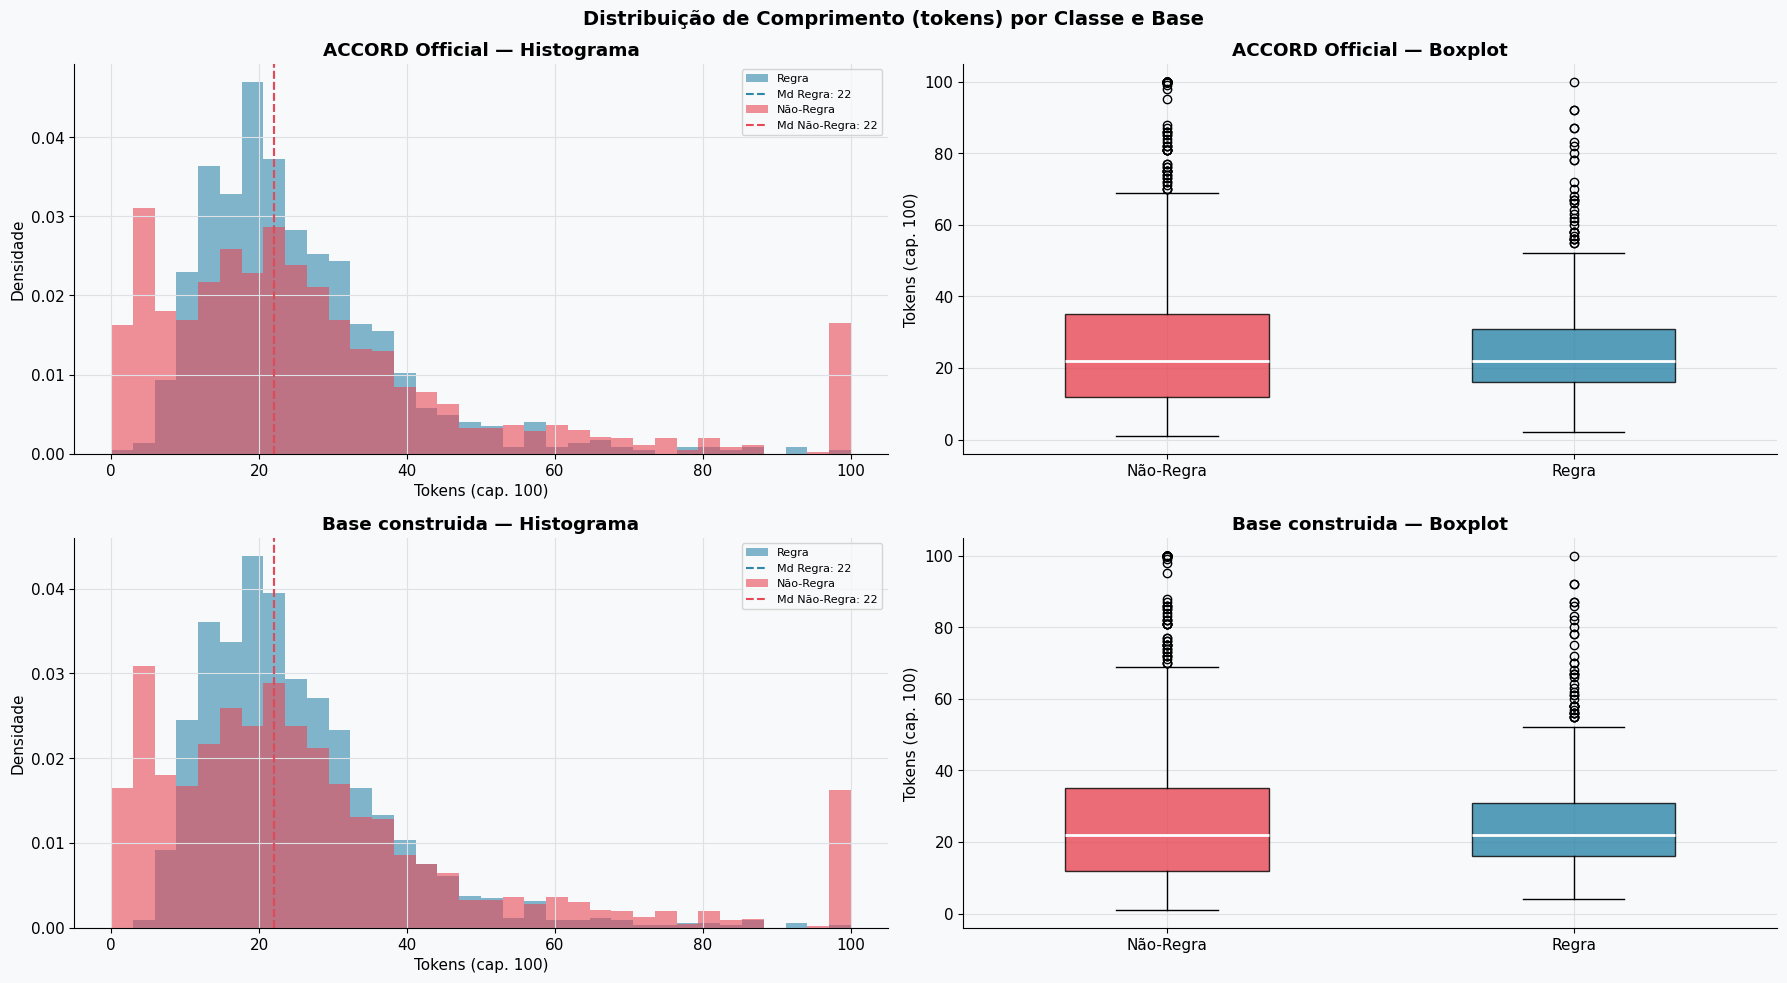

In [37]:
fig, axes = plt.subplots(2, 2, figsize=(18, 10))
fig.suptitle('Distribuição de Comprimento (tokens) por Classe e Base',
             fontsize=14, fontweight='bold')

bases = [
    (df_official, 'ACCORD Official'),
    (df_ours,     'Base construida'),
]

for row, (df_b, bname) in enumerate(bases):
    feats = df_b['Text'].apply(extract_features).apply(pd.Series)
    df_b2 = pd.concat([df_b.reset_index(drop=True), feats], axis=1)

    # Histograma
    ax = axes[row][0]
    bins = np.linspace(0, 100, 35)
    for label, color, lname in [(1,C_RULE,'Regra'),(0,C_NORULE,'Não-Regra')]:
        sub = df_b2[df_b2['is_rule']==label]['n_tokens'].clip(upper=100)
        ax.hist(sub, bins=bins, alpha=0.6, color=color, label=lname, density=True)
        ax.axvline(sub.median(), color=color, linestyle='--', linewidth=1.5,
                   label=f'Md {lname}: {sub.median():.0f}')
    ax.set_title(f'{bname} — Histograma', fontweight='bold')
    ax.set_xlabel('Tokens (cap. 100)')
    ax.set_ylabel('Densidade')
    ax.legend(fontsize=8)

    # Boxplot
    ax2 = axes[row][1]
    data = [df_b2[df_b2['is_rule']==0]['n_tokens'].clip(upper=100),
            df_b2[df_b2['is_rule']==1]['n_tokens'].clip(upper=100)]
    bp = ax2.boxplot(data, patch_artist=True, widths=0.5,
                     medianprops=dict(color='white', linewidth=2))
    for patch, color in zip(bp['boxes'], [C_NORULE, C_RULE]):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)
    ax2.set_xticklabels(['Não-Regra','Regra'])
    ax2.set_title(f'{bname} — Boxplot', fontweight='bold')
    ax2.set_ylabel('Tokens (cap. 100)')

    print(f'{bname} — Número de amostras: {len(df_b2)}')
    print(f'{df_b2.columns} colunas')
    df_b2.to_csv(f'../data/{bname.lower().replace(" ","_")}_features.csv', index=False)
plt.tight_layout()
# plt.savefig('../figures/fig2_comprimento_univariado.png', dpi=150, bbox_inches='tight')
plt.show()


Quando analisamos o comprimento das regras de ambas as bases, podemos perceber que normalmente regras utilizam mais tokens que não regras.
Entretanto ainda existe grande parte das não regars que obtem o mesmo tamanho das regras. Isso é possivel visualizar na mediana de tokens.
Assim podemos ver que a quantidade de tokens pode mão ser um fator discriminanet para nosso modelo classifcatorio.

---
## Análise Bivariada — Marcadores Linguísticos

Investigamos a relação entre características linguísticas e a classe da sentença.

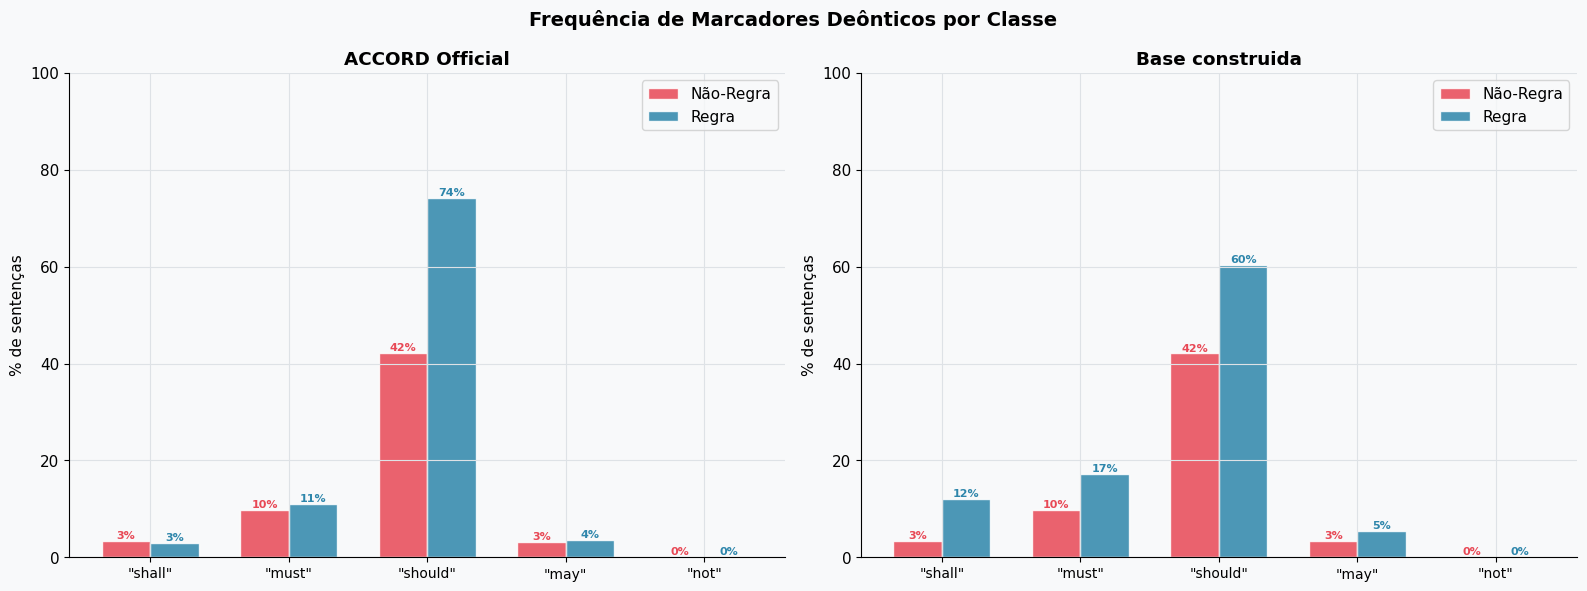

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Frequência de Marcadores Deônticos por Classe',
             fontsize=14, fontweight='bold')

markers     = ['shall','must','should','may','not']
marker_cols = [f'has_{m}' if m != 'not' else 'n_ext_ref' for m in markers]

for ax, (df_b, bname) in zip(axes, [
    (df_official, 'ACCORD Official'),
    (df_ours,     'Base construida'),
]):
    feats = df_b['Text'].apply(extract_features).apply(pd.Series)
    df_b2 = pd.concat([df_b.reset_index(drop=True), feats], axis=1)

    x     = np.arange(len(markers))
    width = 0.35
    r1    = [df_b2[df_b2['is_rule']==1][f'has_{m}'].mean()*100
             if f'has_{m}' in df_b2.columns else 0 for m in markers]
    r0    = [df_b2[df_b2['is_rule']==0][f'has_{m}'].mean()*100
             if f'has_{m}' in df_b2.columns else 0 for m in markers]

    bars0 = ax.bar(x - width/2, r0, width, label='Não-Regra',
                   color=C_NORULE, alpha=0.85, edgecolor='white')
    bars1 = ax.bar(x + width/2, r1, width, label='Regra',
                   color=C_RULE, alpha=0.85, edgecolor='white')

    for bars, vals, color in [(bars0,r0,C_NORULE),(bars1,r1,C_RULE)]:
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                    f'{val:.0f}%', ha='center', fontsize=8,
                    color=color, fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels([f'"{m}"' for m in markers], fontsize=10)
    ax.set_title(bname, fontweight='bold')
    ax.set_ylabel('% de sentenças')
    ax.legend()
    # ax.set_ylim(0, max(max(r0), max(r1)) * 1.3)
    ax.set_ylim(0, 100)

plt.tight_layout()
plt.savefig('../figures/fig3_marcadores_deonticos.png', dpi=150, bbox_inches='tight')
plt.show()


Nesse grafico podemos ver que a frequencia de marcadores deônicos por classe é mais presente na base construida. Sendo um diferencial da base do ACCORD.
Isso se dá pela maneira de construção. Na base porposta nesse trabalho, temos como uma marca maior a anatoçaõ dos dados deitos pelos especialistas, utilizando o baseline para construção.
Enquando a construção do ACCORD é feita a partir dos dados notados pelo CODE. Ou seja do artigo. 

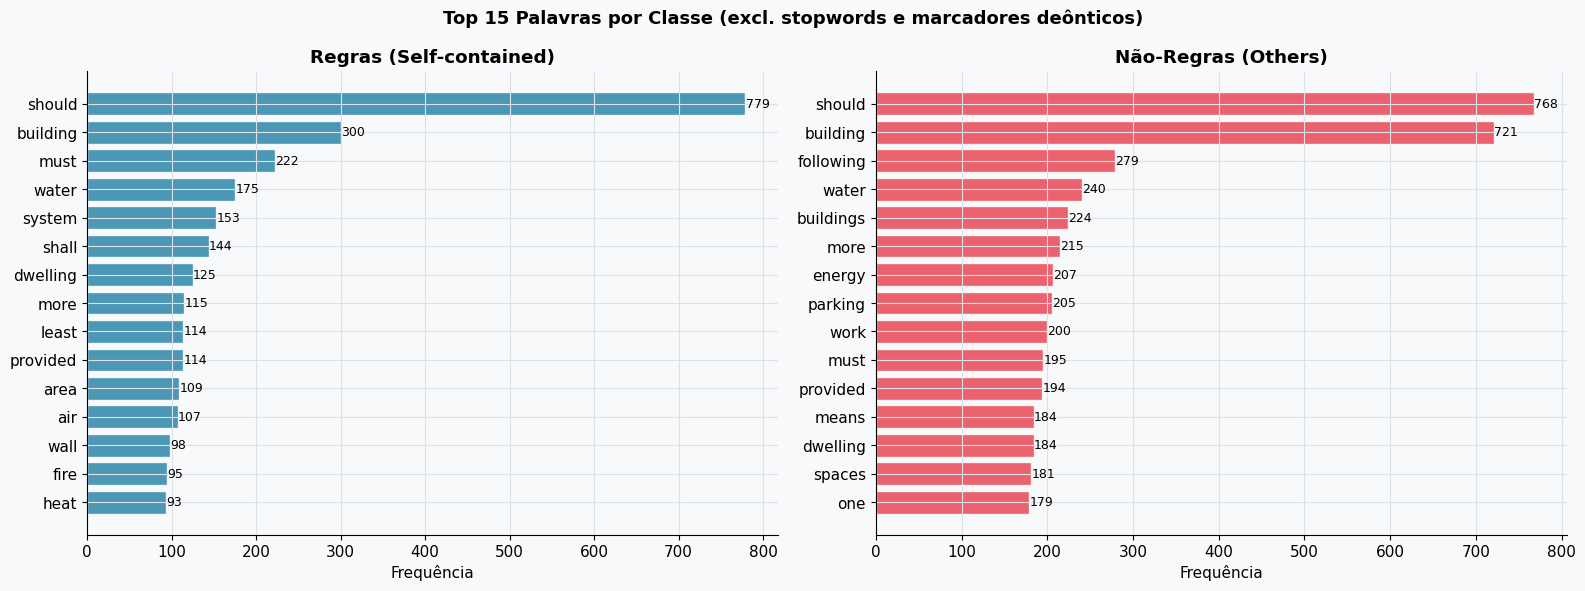

In [20]:
STOPWORDS = {'the','a','an','of','to','in','and','or','is','be','that','with',
             'for','as','on','at','by','from','which','this','are','it','if',
             'not','no','any','all','than','such','where','when','so','its',
             'been','have','has','their','they','into','was','were','will','may'}

def top_words(texts, n=15):
    tokens = []
    for t in texts:
        tokens += [w.lower() for w in re.sub(r'[^\w\s]',' ',str(t)).split()
                   if w.lower() not in STOPWORDS and len(w) > 2]
    return Counter(tokens).most_common(n)

df_vocab = df_tidy.copy()
rules_texts    = df_vocab[df_vocab['is_rule']==1]['Text']
nonrules_texts = df_vocab[df_vocab['is_rule']==0]['Text']

top_r  = top_words(rules_texts)
top_nr = top_words(nonrules_texts)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Top 15 Palavras por Classe (excl. stopwords e marcadores deônticos)',
             fontsize=13, fontweight='bold')

for ax, data, color, title in [
    (axes[0], top_r,  C_RULE,   'Regras (Self-contained)'),
    (axes[1], top_nr, C_NORULE, 'Não-Regras (Others)'),
]:
    words, counts = zip(*data)
    ax.barh(list(reversed(words)), list(reversed(counts)),
            color=color, alpha=0.85, edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Frequência')
    for i, (w, c) in enumerate(zip(reversed(words), reversed(counts))):
        ax.text(c + 0.3, i, str(c), va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../figures/fig4_top_palavras.png', dpi=150, bbox_inches='tight')
plt.show()


É possivel visualizar que temos tokens que repetem em regras e não regras.
Isso se da pelo caso do contexto que esta inserido, no caso `should` é mais um recomendação, não uma regra explicita.

Nas não regras temos a frequencia de mais termos sem obrigatoriedade sendo eles water, energy, space, one. termos que não demsotram obrigação.

Agora quando visualizamos as regras, são termos mais especificos, como must, shall.
Mesmo assim eeles aparecem em não regras, o que apenas mostra que as regras dependem muito do contexto semantico inserido.
Mostrando assim a necessidade de ser anotado dados na mão. 
A partir disso, porpor um modelo de classificação de regras paar auxilixar nesse proximo. 

---
## Inter-Annotator Agreement (IAA) entre Bases

### O que é o IAA?

O **Inter-Annotator Agreement** mede o grau de concordância entre diferentes "anotadores"
ao classificar os mesmos dados. No artigo original do CODE-ACCORD, o IAA foi calculado
entre anotadores humanos para entidades, obtendo média de **0.37** (escala 0–1).

No nosso contexto, cada base de dados representa uma "perspectiva de anotação" diferente:
- As bases foram construídas a partir de fontes distintas do mesmo corpus
- As mesmas sentenças podem ter rótulos diferentes entre bases

Usamos o **Cohen's Kappa (κ)**, a métrica padrão para concordância em classificação binária,
que desconta o acerto esperado por acaso.

**Interpretação do κ:**

| κ | Concordância |
|---|---|
| < 0.20 | Fraca |
| 0.21 – 0.40 | Razoável |
| 0.41 – 0.60 | Moderada |
| 0.61 – 0.80 | Substancial |
| > 0.80 | Quase perfeita |


In [21]:
def compute_kappa(df_a, df_b, name_a, name_b):
    merged = pd.merge(
        df_a[['Text','is_rule']].rename(columns={'is_rule': 'label_a'}),
        df_b[['Text','is_rule']].rename(columns={'is_rule': 'label_b'}),
        on='Text', how='inner'
    )
    if len(merged) == 0:
        return {'par': f'{name_a} vs {name_b}', 'overlap': 0,
                'kappa': None, 'concordancia': None, 'conflitos': None}

    kappa    = cohen_kappa_score(merged['label_a'], merged['label_b'])
    concord  = (merged['label_a'] == merged['label_b']).mean() * 100
    conflitos = (merged['label_a'] != merged['label_b']).sum()

    # Confusion matrix manual
    tp = ((merged['label_a']==1) & (merged['label_b']==1)).sum()
    tn = ((merged['label_a']==0) & (merged['label_b']==0)).sum()
    fp = ((merged['label_a']==0) & (merged['label_b']==1)).sum()
    fn = ((merged['label_a']==1) & (merged['label_b']==0)).sum()

    return {
        'Par':              f'{name_a}  ↔  {name_b}',
        'Sentenças comuns': len(merged),
        'Concordância %':   round(concord, 1),
        'Conflitos':        conflitos,
        'κ (Kappa)':        round(kappa, 3),
        'TP': tp, 'TN': tn, 'FP': fp, 'FN': fn
    }

results_iaa = [
    compute_kappa(df_official, df_ours, 'ACCORD Official', 'Base construida'),
]

df_iaa = pd.DataFrame(results_iaa)
df_iaa
# df_iaa.to_csv('iaa_comparison.csv', index=False)


,Par,Sentenças comuns,Concordância %,Conflitos,κ (Kappa),TP,TN,FP,FN
0,ACCORD Official ↔ Base construida,2160,99.5,11,0.989,714,1435,0,11


Comparando "ACCORD Official" vs "Base construida" — Sentenças comuns: 2160
Comparando "ACCORD Official" vs "ALL (Baseline)" — Sentenças comuns: 557
Comparando "Base construida" vs "ACCORD Official" — Sentenças comuns: 2160
Comparando "Base construida" vs "ALL (Baseline)" — Sentenças comuns: 862
Comparando "ALL (Baseline)" vs "ACCORD Official" — Sentenças comuns: 557
Comparando "ALL (Baseline)" vs "Base construida" — Sentenças comuns: 862


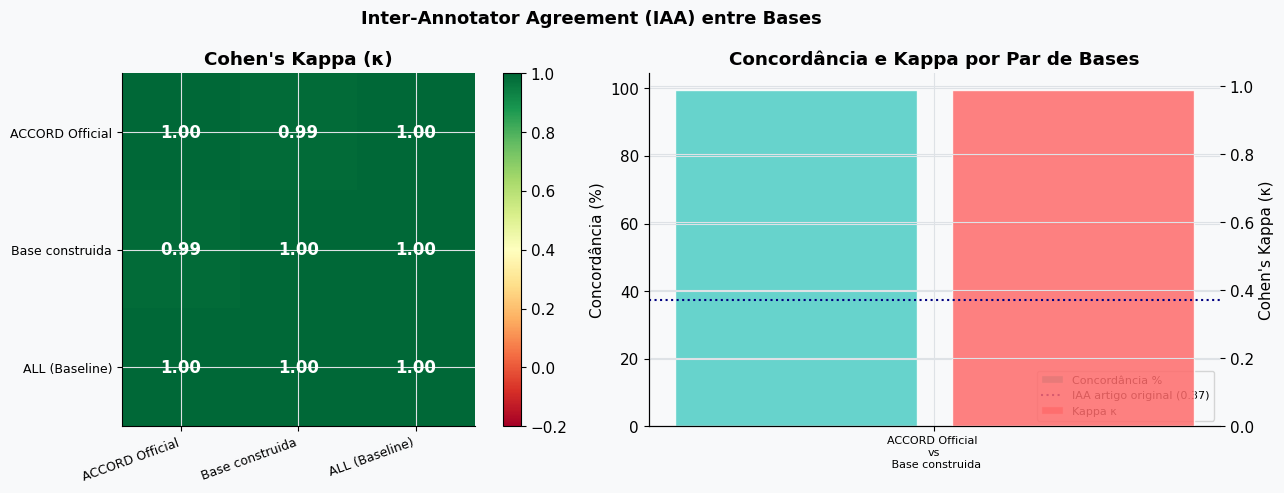

In [22]:
bases_names = ['ACCORD Official', 'Base construida', 'ALL (Baseline)']
bases_dfs   = [df_official, df_ours, df_all]

kappa_matrix = np.ones((3, 3))
for i in range(3):
    for j in range(3):
        if i != j:
            merged = pd.merge(
                bases_dfs[i][['Text','is_rule']].rename(columns={'is_rule':'a'}),
                bases_dfs[j][['Text','is_rule']].rename(columns={'is_rule':'b'}),
                on='Text', how='inner'
            )
            print(f'Comparando "{bases_names[i]}" vs "{bases_names[j]}" — Sentenças comuns: {len(merged)}')
            if len(merged) > 1 and merged['a'].nunique() > 1:
                try:
                    kappa_matrix[i][j] = cohen_kappa_score(merged['a'], merged['b'])
                except:
                    kappa_matrix[i][j] = 0
# print("Tamanho da base com INNER JOIN:", len(merged))
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Inter-Annotator Agreement (IAA) entre Bases', fontsize=13, fontweight='bold')

# Heatmap de Kappa
ax1 = axes[0]
im = ax1.imshow(kappa_matrix, cmap='RdYlGn', vmin=-0.2, vmax=1.0)
ax1.set_xticks(range(3))
ax1.set_yticks(range(3))
ax1.set_xticklabels(bases_names, rotation=20, ha='right', fontsize=9)
ax1.set_yticklabels(bases_names, fontsize=9)
ax1.set_title("Cohen's Kappa (κ)", fontweight='bold')
for i in range(3):
    for j in range(3):
        val = kappa_matrix[i][j]
        label_str = f'{val:.2f}' if i != j else '1.00'
        color_txt = 'black' if 0.3 < val < 0.7 else 'white'
        ax1.text(j, i, label_str, ha='center', va='center',
                 fontsize=12, fontweight='bold', color=color_txt)
plt.colorbar(im, ax=ax1, fraction=0.046)

# Barras de concordância por par
ax2 = axes[1]
pairs  = [r['Par'] for r in results_iaa]
concds = [r['Concordância %'] for r in results_iaa]
kappas = [r['κ (Kappa)'] for r in results_iaa]
x = np.arange(len(pairs))
b1 = ax2.bar(x - 0.2, concds, 0.35, label='Concordância %',
             color='#4ECDC4', alpha=0.85, edgecolor='white')
ax2_twin = ax2.twinx()
b2 = ax2_twin.bar(x + 0.2, kappas, 0.35, label="Kappa κ",
                  color='#FF6B6B', alpha=0.85, edgecolor='white')
ax2.set_xticks(x)
ax2.set_xticklabels([p.replace(' ↔ ', '\nvs\n') for p in pairs], fontsize=8)
ax2.set_ylabel('Concordância (%)')
ax2_twin.set_ylabel("Cohen's Kappa (κ)")
ax2_twin.axhline(0.37, color='navy', linestyle=':', linewidth=1.5,
                 label='IAA artigo original (0.37)')
ax2.set_title('Concordância e Kappa por Par de Bases', fontweight='bold')
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_twin.get_legend_handles_labels()
ax2.legend(lines1+lines2, labels1+labels2, loc='lower right', fontsize=8)

plt.tight_layout()
plt.savefig('../figures/fig5_iaa_bases.png', dpi=150, bbox_inches='tight')
plt.show()


Uma metrica interresante para comparar base de dados, é o IAA.
Como explicado acima ela visa verificar se oa anotadores de dados concordam diante das sentenças. 

Como visto na matriz, há grande concordancia das bases com os baselines.
Isso se dá pela construção das bases serem feitas de maneira diferente. A metrica Cohen's Kappa exige que seja feito um INNER JOIN, seja selecionar as sentenças iguais para ver os labels delas.
A base contruida foi em cima do ALL (Baseline), por isso a concordancia de 1.
O ACCORD tambem contem algumas sentnças do ALL (Baseline), por isso 1.

Quando analisado a base do ACCORD e a proposta nesse trabalho, é possivl verificar 11 conflitos. Na base proposta deste trabalho, a construção foi utilizada as anotações e aquelas se foi utilizado uma anotação manual de cada sentença. Utilizando as mesmas metricas feita no artigo. 


In [23]:
df_conflitos = pd.merge(
    df_official[['Text', 'is_rule']].rename(columns={'is_rule': 'label_accord'}),
    df_ours[['Text', 'is_rule']].rename(columns={'is_rule': 'label_construida'}),
    on='Text', 
    how='inner'
)

df_divergencias = df_conflitos[df_conflitos['label_accord'] != df_conflitos['label_construida']]
df_divergencias

,Text,label_accord,label_construida
69,"0.4 In the Secretary of States view, for the ...",1,0.0
461,Common areas in buildings that contain multipl...,1,0.0
471,Compliance should be assessed against only one...,1,0.0
575,Ensuring that equipment is appropriately and s...,1,0.0
785,"However, building work may be subject to more ...",1,0.0
925,"In accordance with regulation 7, building work...",1,0.0
987,"In this case, too, the extension and the modif...",1,0.0
1112,Minor works.,1,0.0
1227,PART Q SECURITY.,1,0.0
1437,Table 0.1 Residential buildings within the sc...,1,0.0


---
## Análise Multivariada

### PCA e Clustering

Redução dimensional via **PCA** sobre features TF-IDF para visualizar a separabilidade
das classes no espaço vetorial. Complementado por **K-Means** para verificar se
agrupamento não-supervisionado recupera as classes naturalmente.


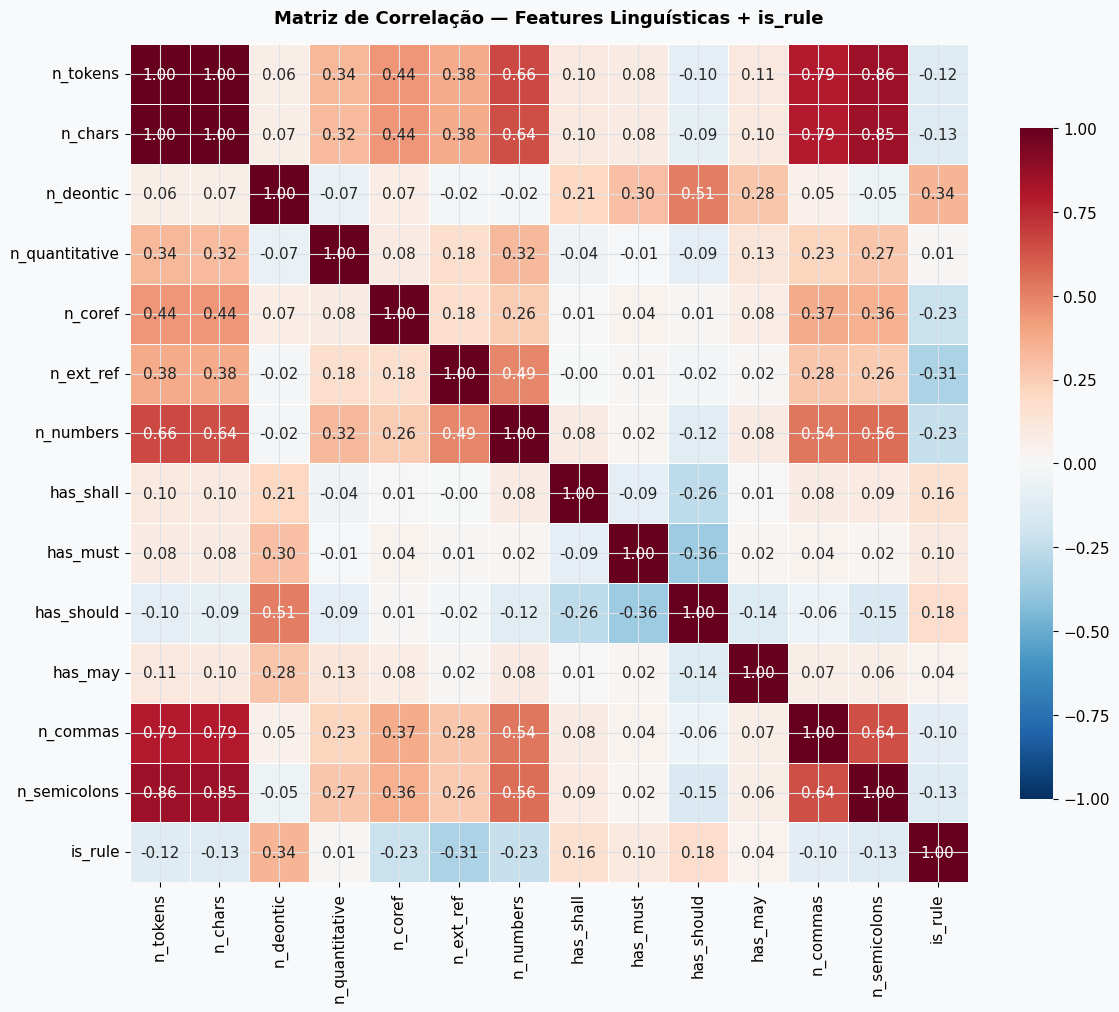

In [24]:
feat_corr_cols = ['n_tokens','n_chars','n_deontic','n_quantitative',
                  'n_coref','n_ext_ref','n_numbers','has_shall',
                  'has_must','has_should','has_may','n_commas','n_semicolons']

df_corr = df_tidy[feat_corr_cols + ['is_rule']].dropna()
corr_matrix = df_corr.corr()

fig, ax = plt.subplots(figsize=(12, 10))
# mask = np.zeros_like(corr_matrix, dtype=bool)
# mask[np.triu_indices_from(mask)] = True

# sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
sns.heatmap(corr_matrix, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Matriz de Correlação — Features Linguísticas + is_rule',
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../figures/fig6_correlacao.png', dpi=150, bbox_inches='tight')
plt.show()

Verificando a matriz de correlação com a variável alvo `is_rule`.
Podemos verificar que as variáveis que correlacionam são `n_deontic`, `has_shall` e `has_should`, com muito mais correlação a marcadores deônicos.
Vamos verificar isso melhor em nossa H2, mas verificamos que é um atributo citado no artigo que faz com que classifiquemos melhor se é ou não uma regra, sendo o mais discriminante para esse tipo de tarefa.

In [25]:
corr_with_label = corr_matrix['is_rule'].drop('is_rule').sort_values(ascending=False)
print(corr_with_label.round(3).to_string())


n_deontic         0.337
has_should        0.182
has_shall         0.161
has_must          0.101
has_may           0.042
n_quantitative    0.011
n_commas         -0.104
n_tokens         -0.123
n_semicolons     -0.126
n_chars          -0.127
n_coref          -0.226
n_numbers        -0.235
n_ext_ref        -0.314


   Variância explicada: PC1=1.9% | PC2=1.7%


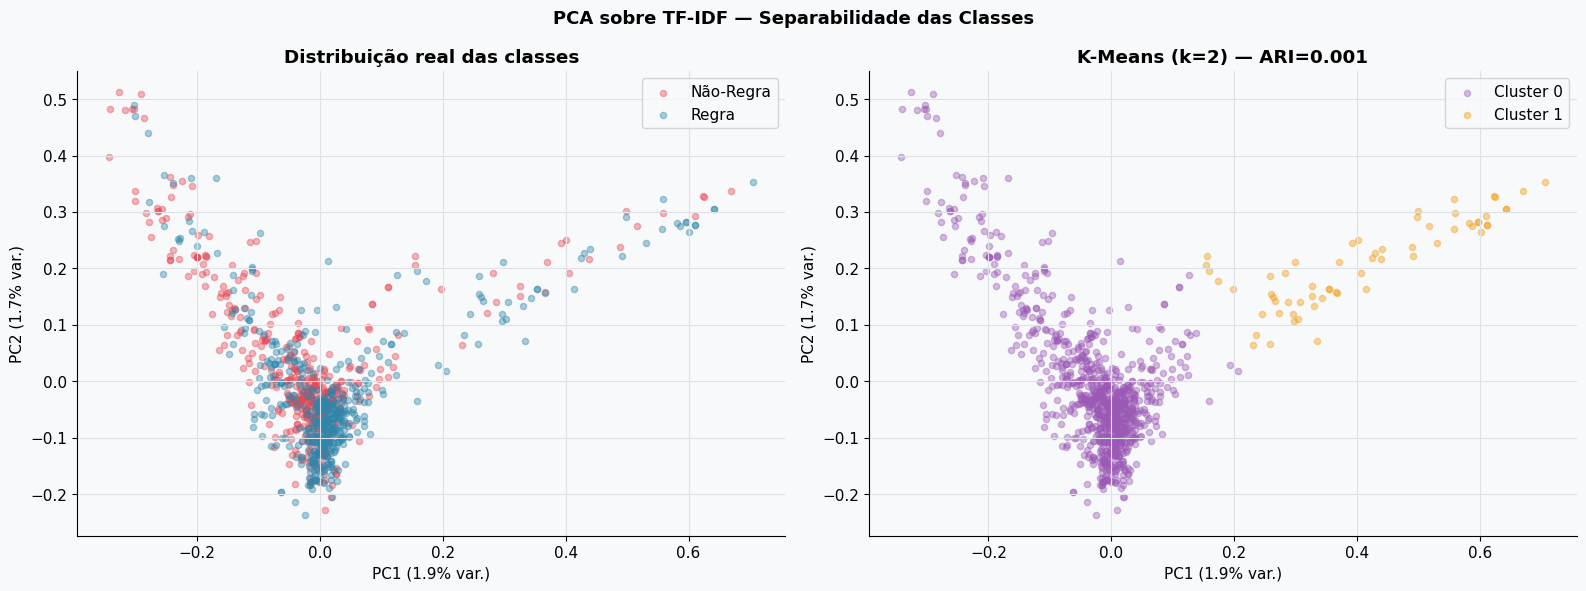

In [26]:
# Amostra balanceada para visualização
n_sample = min(500, (df_tidy['is_rule']==0).sum(), (df_tidy['is_rule']==1).sum())
df_sample = pd.concat([
    df_tidy[df_tidy['is_rule']==0].sample(n_sample, random_state=42),
    df_tidy[df_tidy['is_rule']==1].sample(n_sample, random_state=42),
]).reset_index(drop=True)

# TF-IDF com unigramas e bigramas
tfidf = TfidfVectorizer(ngram_range=(1,2), max_features=500, stop_words='english')
X_tfidf = tfidf.fit_transform(df_sample['Text'].fillna('')).toarray()

# PCA → 2D
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_tfidf)

var_exp = pca.explained_variance_ratio_ * 100
print(f'   Variância explicada: PC1={var_exp[0]:.1f}% | PC2={var_exp[1]:.1f}%')

# Plota PCA
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('PCA sobre TF-IDF — Separabilidade das Classes', fontsize=13, fontweight='bold')

# PCA puro
ax1 = axes[0]
for label, color, name in [(0, C_NORULE, 'Não-Regra'), (1, C_RULE, 'Regra')]:
    mask = df_sample['is_rule'] == label
    ax1.scatter(X_pca[mask, 0], X_pca[mask, 1], c=color, alpha=0.4,
                s=20, label=name)
ax1.set_xlabel(f'PC1 ({var_exp[0]:.1f}% var.)')
ax1.set_ylabel(f'PC2 ({var_exp[1]:.1f}% var.)')
ax1.set_title('Distribuição real das classes', fontweight='bold')
ax1.legend()

# K-Means sobre PCA
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_pca)

# Alinha os clusters com os labels reais
from sklearn.metrics import adjusted_rand_score
ari = adjusted_rand_score(df_sample['is_rule'], clusters)

ax2 = axes[1]
for c, color in [(0,'#9B59B6'),(1,'#F39C12')]:
    mask = clusters == c
    ax2.scatter(X_pca[mask, 0], X_pca[mask, 1], c=color, alpha=0.4, s=20,
                label=f'Cluster {c}')
ax2.set_xlabel(f'PC1 ({var_exp[0]:.1f}% var.)')
ax2.set_ylabel(f'PC2 ({var_exp[1]:.1f}% var.)')
ax2.set_title(f'K-Means (k=2) — ARI={ari:.3f}', fontweight='bold')
ax2.legend()

plt.tight_layout()
plt.savefig('../figures/fig7_pca_clustering.png', dpi=150, bbox_inches='tight')
plt.show()



In [27]:
ari

0.000791327409156384

Para essa etapa, como dito antes, fizemos a transformação das sentenças em vetores TF-IDF e colocamos em um `Scatterplot`, sendo o vermelho não regra e o azul regra.
O gráfico nos mostra que a classificação apenas utilizando esse tipo de vetorização pode ser limitada, pois os pontos estão muito próximos e não são características determinantes sobre essas sentenças.
A diferença é muito sutil. A fim de visualizar essa diferença, utilizamos o modelo de aprendizagem não supervisionado com $k=2$ para classificar e validar essa diferença. Como visto, a métrica ARi foi muito baixa, próxima a 0; isso significa que o modelo não obteve um desempenho significativo para essa tarefa.


Isso evidencia o desafio de classificação de texto para o cenário de regulamentação civil.


---
## Testes de Hipóteses


In [28]:
grupo_regra = df_tidy[df_tidy['is_rule'] == 1]
grupo_nao_regra = df_tidy[df_tidy['is_rule'] == 0]

H2: Regras apresentam frequência significativamente maior de marcadores deônticos?

In [29]:
df_test = df_tidy.copy()

for feature, feat_name in [
    ('n_deontic',      'Nº de marcadores deônticos'),
    ('has_shall',      'Presença de "shall"'),
    ('has_must',       'Presença de "must"'),
    ('has_should',     'Presença de "should"'),
    ('n_quantitative', 'Nº de marcadores quantitativos'),
]:
    group_1 = df_test[df_test['is_rule']==1][feature]
    group_0 = df_test[df_test['is_rule']==0][feature]

    stat, p = mannwhitneyu(group_1, group_0, alternative='greater')

    if p < 0.05:
        sig = 'significativo'
    else:
        sig = 'não significativo'

    print(f'{feat_name}')
    print(f'Média regra={group_1.mean():.3f} | Média não-regra={group_0.mean():.3f}')
    print(f'Mann-Whitney U={stat:.0f} | p={p:.4f} | {sig}')
    print()

Nº de marcadores deônticos
Média regra=0.972 | Média não-regra=0.614
Mann-Whitney U=1409496 | p=0.0000 | significativo

Presença de "shall"
Média regra=0.119 | Média não-regra=0.036
Mann-Whitney U=1141737 | p=0.0000 | significativo

Presença de "must"
Média regra=0.168 | Média não-regra=0.100
Mann-Whitney U=1125724 | p=0.0000 | significativo

Presença de "should"
Média regra=0.603 | Média não-regra=0.419
Mann-Whitney U=1248057 | p=0.0000 | significativo

Nº de marcadores quantitativos
Média regra=0.248 | Média não-regra=0.236
Mann-Whitney U=1080330 | p=0.0478 | significativo



Analisando o teste, vemos que as regras tem a presença maior de tokens especificos. 
Entretanto, quando analisamos não regras, tambem vimos que há presença desses marcadores.
Entretanto ela acaba se sobrepondo quando é uam regra.
Assim a presença de marcadores deônicos, `must` e `should` mostram que podem ser um diferencial pra classificação de regras e não regras.

H3: Regras possuem comprimento diferente E é preditor relevante?

In [30]:
# Parte 1: Diferença estatística (alternative='two-sided')
stat_h3, p_val_h3 = mannwhitneyu(
    grupo_regra['n_tokens'].dropna(), 
    grupo_nao_regra['n_tokens'].dropna(), 
    alternative='two-sided'
)

print(f"Mediana (Regras): {grupo_regra['n_tokens'].median()} | Mediana (Others): {grupo_nao_regra['n_tokens'].median()}")
print(f"Estatística U: {stat_h3:.2f} | P-valor: {p_val_h3:.4e}")

if p_val_h3 < 0.05:
    print("Rejeitamos H3. O comprimento é estatisticamente diferente entre as classes.")
else:
    print("Falhamos em rejeitar H3. O comprimento pode não ser diferente entre as classes.")

Mediana (Regras): 22.0 | Mediana (Others): 23.0
Estatística U: 1054718.50 | P-valor: 9.6905e-01
Falhamos em rejeitar H3. O comprimento pode não ser diferente entre as classes.


In [31]:
# Verificar se é preditivo isolado
from sklearn.metrics import roc_auc_score

auc_h3 = roc_auc_score(df_tidy['is_rule'], df_tidy['n_tokens'])

print("AUC para n_tokens como preditor isolado:", round(auc_h3, 3))

if auc_h3 > 0.60:
    print("O comprimento é estatisticamente diferente e atua como preditor válido.")
else:
    print("A diferença existe, mas o poder preditivo isolado pode ser fraco.")


AUC para n_tokens como preditor isolado: 0.5
A diferença existe, mas o poder preditivo isolado pode ser fraco.


O teste indica que utilizar o n_tokens pode não ser a melhor abordagem para o modelo. 
Podemos verificar que o AUC tem valor 0.5, indicando que a probabilidade é igual "chutar", ou seja verificar a sorte na clssificação. 
Ele não consegue aprender.
Dessa forma, chegamos a conclusão que a feature de quantidade de tokens é irrelvante para classificção de regras e não regras.

In [32]:
df_tidy.columns

Index(['Text', 'is_rule', 'base', 'n_tokens', 'n_chars', 'n_deontic',
       'n_quantitative', 'n_coref', 'n_ext_ref', 'has_shall', 'has_must',
       'has_should', 'has_may', 'starts_capital', 'ends_period', 'n_commas',
       'n_semicolons', 'n_numbers'],
      dtype='object')

> Por curiosidade: Listei todas as demais colunas para saber o poder preditivo delas.

In [33]:
d = {}
for feature in ['n_chars', 'n_deontic','n_quantitative', 'n_coref', 'n_ext_ref', 'has_shall', 'has_must',
       'has_should', 'has_may', 'starts_capital', 'ends_period', 'n_commas','n_semicolons', 'n_numbers']:

    auc_h3 = roc_auc_score(df_tidy['is_rule'], df_tidy[feature])
    d[feature] = auc_h3
    
df = pd.DataFrame.from_dict(d, orient='index', columns=['AUC']).sort_values('AUC', ascending=False)
df


,AUC
n_deontic,0.668745
has_should,0.592150
starts_capital,0.561999
has_shall,0.541705
has_must,0.534108
n_quantitative,0.512571
has_may,0.508705
ends_period,0.500068
n_chars,0.497275
n_commas,0.486634


TF-IDF 

X-BOOST